# Training a binary classifier (Mini-batch GD, B=4) - PyTorch Version

We train with mini-batch gradient descent (batch size B=4) using PyTorch with hooks to capture gradients and intermediate computations.

/home/j/anaconda3/envs/infusion/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


Using device: cpu
Data shape: X=(400, 2), y=(400,)
Initial parameters:
Weight: tensor([[-0.0208, -0.1954]])
Bias: tensor([0.])

Learned parameters (PyTorch mini-batch GD):
Weight: tensor([[2.0284, 2.5268]])
Bias: tensor([-4.2287])
Final BCE loss: 0.066235
Accuracy: 98.25%


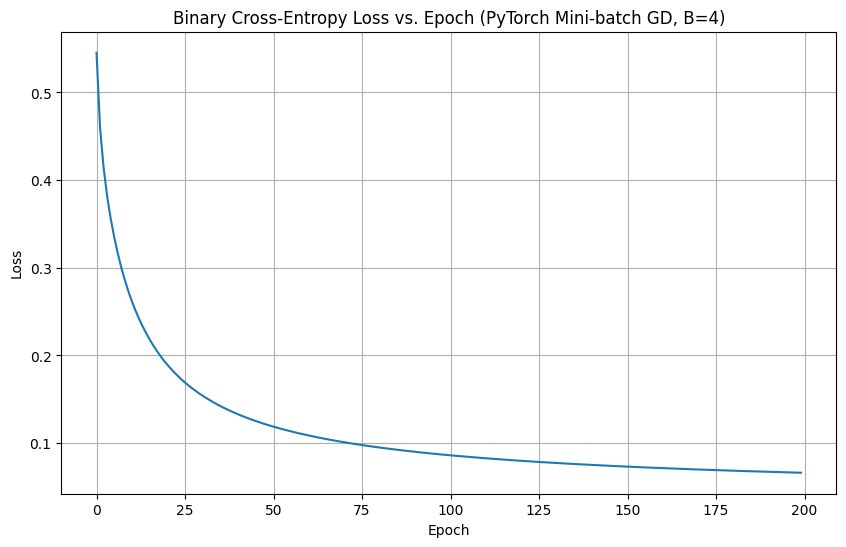

Probe (x*, y*) = [ 0.29983354 -0.27373934], 1.0


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

B = 32  # batch size
RANDOM_SEED = 48

# Set device and reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Using device: {device}")

# ---- 1) Create mock data ----
n_per_class = 200
rng = np.random.default_rng(RANDOM_SEED)

# "Blue" class (label 0)
blue_mean = np.array([0.0, 0.0])
blue_cov = np.array([[0.5, 0.1],
                     [0.1, 0.5]])
X_blue = rng.multivariate_normal(blue_mean, blue_cov, size=n_per_class)
y_blue = np.zeros(n_per_class, dtype=int)

# "Red" class (label 1)
red_mean = np.array([2.0, 2.0])
red_cov = np.array([[0.6, -0.1],
                    [-0.1, 0.6]])
X_red = rng.multivariate_normal(red_mean, red_cov, size=n_per_class)
y_red = np.ones(n_per_class, dtype=int)

# Stack & shuffle
X = np.vstack([X_blue, X_red])  # (N, 2)
y = np.concatenate([y_blue, y_red])
N, D = X.shape
perm = rng.permutation(N)
X = X[perm]; y = y[perm]

# Convert to tensors
X_tensor = torch.FloatTensor(X).to(device)
y_tensor = torch.FloatTensor(y).to(device)

print(f"Data shape: X={X.shape}, y={y.shape}")

# ---- 2) Define PyTorch Logistic Regression Model ----
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
        
        # Initialize with small weights like numpy version
        nn.init.normal_(self.linear.weight, mean=0, std=0.1)
        nn.init.zeros_(self.linear.bias)
    
    def forward(self, x):
        return torch.sigmoid(self.linear(x)).squeeze()

# Create model
model = LogisticRegression(D).to(device)
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

print(f"Initial parameters:")
print(f"Weight: {model.linear.weight.data}")
print(f"Bias: {model.linear.bias.data}")

# ---- 3) Training with mini-batch GD ----
epochs = 200

loss_history = []

# Create dataset and dataloader
dataset = TensorDataset(X_tensor, y_tensor)

for epoch in range(epochs):
    # Shuffle data each epoch
    indices = torch.randperm(N)
    X_epoch = X_tensor[indices]
    y_epoch = y_tensor[indices]
    
    # Mini-batch training
    for start in range(0, N, B):
        end = min(start + B, N)
        X_batch = X_epoch[start:end]
        y_batch = y_epoch[start:end]
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
    
    # Track full-data loss
    with torch.no_grad():
        full_outputs = model(X_tensor)
        full_loss = criterion(full_outputs, y_tensor)
        loss_history.append(full_loss.item())

# Final metrics
with torch.no_grad():
    final_outputs = model(X_tensor)
    predictions = (final_outputs >= 0.5).float()
    accuracy = (predictions == y_tensor).float().mean().item()

print("\nLearned parameters (PyTorch mini-batch GD):")
print(f"Weight: {model.linear.weight.data}")
print(f"Bias: {model.linear.bias.data}")
print(f"Final BCE loss: {loss_history[-1]:.6f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Plot loss
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.title("Binary Cross-Entropy Loss vs. Epoch (PyTorch Mini-batch GD, B=4)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Store original parameters for later use
w_orig = model.linear.weight.data.clone()
b_orig = model.linear.bias.data.clone()

# ---- Probe (x*, y*) ----
x_star = torch.FloatTensor(2).uniform_(-2, 2).to(device)
y_star = torch.randint(0, 2, (1,)).float().to(device)

print(f"Probe (x*, y*) = {x_star.cpu().numpy()}, {y_star.item()}")

# Batchwise norm-budget perturbation (PGD, optimizer-aware, B=4) - PyTorch with Hooks

Batch indices S = [333, 382, 246, 398, 339, 207, 1, 114, 373, 280, 217, 300, 169, 132, 362, 345, 206, 108, 171, 185, 285, 346, 95, 279, 390, 204, 303, 236, 112, 85, 227, 328]
Probe (x*, y*) = [ 0.29983354 -0.27373934], 1.0
f(θ) before = 0.720393 ; after = 0.750732 ; Δ = +0.030339


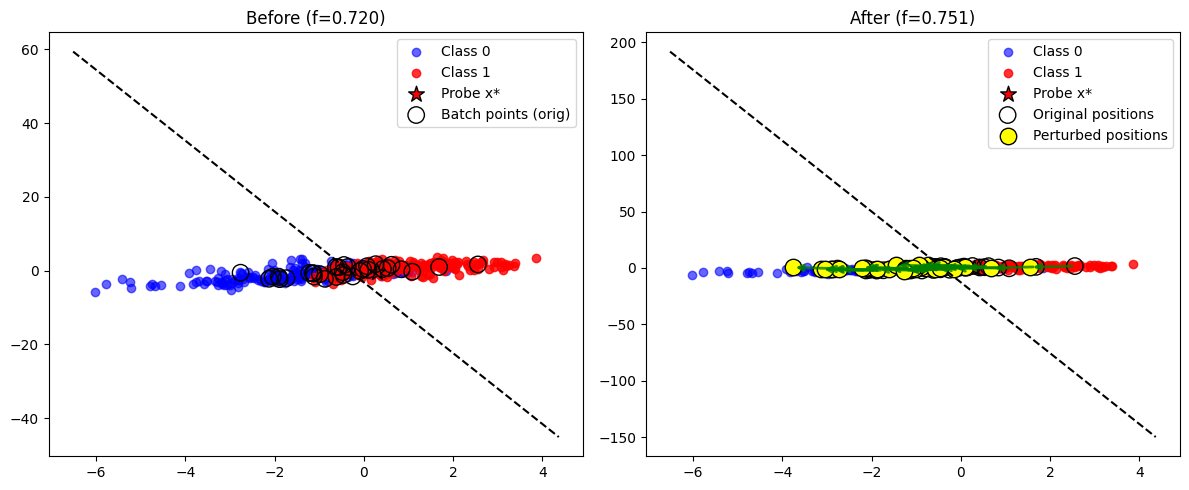

In [22]:
import torch
import torch.nn.functional as F
from torch.autograd import grad
import matplotlib.pyplot as plt


def grad_f_logprob(x_star, y_star, model):
    """Compute ∇_θ f where f is the probability of the correct class"""
    model.zero_grad()
    
    # Forward pass
    p_star = model(x_star.unsqueeze(0)).squeeze()
    
    # This matches the NumPy version: (y_star - p_star) * [x_star, 1]
    # We need to manually compute the gradient since NumPy version is analytical
    diff = (y_star - p_star)
    grad_w = diff * x_star              # (D,)
    grad_b = diff.reshape(1)            # (1,)
    
    return torch.cat([grad_w, grad_b], dim=0)  # (D+1,)

# Cross-Jacobian J = ∇_x ∇_θ ℓ for logistic regression
def cross_jacobian_x_theta(x, y_label, model):
    """Compute ∇_x ∇_θ ℓ using PyTorch autograd"""
    x = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    
    # Forward pass
    output = model(x.unsqueeze(0)).squeeze()
    
    # Binary cross entropy loss for this single example
    loss = F.binary_cross_entropy(output, y_label.float(), reduction='none')
    
    # First-order gradients w.r.t. parameters
    grad_theta = grad(loss, model.parameters(), create_graph=True, retain_graph=True)
    grad_w, grad_b = grad_theta[0].squeeze(), grad_theta[1]
    grad_theta_concat = torch.cat([grad_w, grad_b])
    
    # Cross derivatives: ∇_x (∇_θ ℓ)
    cross_jacobian = []
    for i in range(len(grad_theta_concat)):
        if grad_theta_concat[i].requires_grad:
            cross_grad = grad(grad_theta_concat[i], x, retain_graph=True, allow_unused=True)[0]
            if cross_grad is not None:
                cross_jacobian.append(cross_grad)
            else:
                cross_jacobian.append(torch.zeros_like(x))
        else:
            cross_jacobian.append(torch.zeros_like(x))
    
    return torch.stack(cross_jacobian)                                # ((D+1)×D)

# Projection operators
def proj_linf(x0, x_candidate, eps):
    return torch.clamp(x_candidate, x0 - eps, x0 + eps)
def proj_l2(x0, x_candidate, eps):
    d = x_candidate - x0
    n = torch.norm(d, p=2)
    if n <= eps or n == 0:
        return x_candidate
    return x0 + d * (eps / n)

# Quick mini-batch refit (same regime as above)
def train_minibatch(X, y, lr=0.05, epochs=150, B=4):
    """Train a fresh model on the given data using mini-batch SGD"""
    model_new = LogisticRegression(X.shape[1]).to(device)
    optimizer_new = optim.SGD(model_new.parameters(), lr=lr)
    criterion = nn.BCELoss()
    
    N = X.shape[0]
    for ep in range(epochs):
        indices = torch.randperm(N, device=device)
        X_ep = X[indices]; y_ep = y[indices]
        for start in range(0, N, B):
            end = min(start + B, N)
            Xb = X_ep[start:end]; yb = y_ep[start:end]
            Bb = Xb.shape[0]
            optimizer_new.zero_grad()
            z = model_new(Xb)
            loss = criterion(z, yb)
            loss.backward()
            optimizer_new.step()
    return model_new

# ----------------------------
# Choose a concrete mini-batch S (size B=4) to perturb
# Strategy: take the next contiguous 4 examples after a fresh shuffle.
# You can swap this for any batch selection scheme you like.
# ----------------------------
B = B
perm2 = torch.randperm(N, device=device)
S_idx = perm2[:B]
print("Batch indices S =", S_idx.tolist())

# ----------------------------
# PGD settings (per-example L∞ or L2 budget)
# ----------------------------
EPSILON = 1.0      # norm radius (increased for visibility)
ALPHA   = 0.15     # step size (increased for faster convergence)
P_NORM  = "inf"    # "inf" or "2"
N_STEPS = int(torch.ceil(torch.tensor(EPSILON / ALPHA)).item()) if P_NORM=="inf" else 15

# ----------------------------
# Compute optimizer-aware directions G_j = -(η/B) J_j^T ∇_θ f
# ----------------------------
eta = 0.05   # learning rate used in training loop
g_f = grad_f_logprob(x_star, y_star, model)         # (D+1,)

X0_batch = X_tensor[S_idx].clone().detach()
y_batch = y_tensor[S_idx].clone().detach()
X_adv = X0_batch.clone().detach()

for step in range(N_STEPS):
    # (optionally re-evaluate g_f each inner step; usually small change, skip for speed)
    # g_f = grad_f_logprob(x_star, y_star, model)

    for j_local in range(len(S_idx)):
        j = S_idx[j_local]
        xj0 = X0_batch[j_local]
        yj = y_batch[j_local]

        # J_j at current params
        Jj = cross_jacobian_x_theta(X_adv[j_local], yj, model)  # ((D+1)×D)

        # G_j = -(η/B) * J_j^T * ∇_θ f
        Gj = -(eta / B) * (Jj.T @ g_f)                        # (D,)

        # PGD step + projection
        if P_NORM == "inf":
            step_vec = ALPHA * torch.sign(Gj)
            cand = X_adv[j_local] + step_vec
            X_adv[j_local] = proj_linf(xj0, cand, EPSILON)
        else:
            gnorm = torch.norm(Gj, p=2) + 1e-12
            step_vec = ALPHA * (Gj / gnorm)
            cand = X_adv[j_local] + step_vec
            X_adv[j_local] = proj_l2(xj0, cand, EPSILON)

# Replace the B points with their crafted versions
X_pert = X_tensor.clone().detach()  # Detach to avoid gradient graph issues
X_pert[S_idx] = X_adv.detach()      # Ensure X_adv is also detached

# ----------------------------
# Evaluate f(θ) before/after retraining (mini-batch regime)
# ----------------------------
with torch.no_grad():
    p_star_before = model(x_star.unsqueeze(0)).squeeze()
    f_before = p_star_before.item() if y_star.item()==1 else (1 - p_star_before.item())

model_new = train_minibatch(X_pert, y_tensor, lr=0.05, epochs=200, B=B)

with torch.no_grad():
    p_star_after = model_new(x_star.unsqueeze(0)).squeeze()
    f_after = p_star_after.item() if y_star.item()==1 else (1 - p_star_after.item())

print(f"Probe (x*, y*) = {x_star.cpu().numpy()}, {y_star.item()}")
print(f"f(θ) before = {f_before:.6f} ; after = {f_after:.6f} ; Δ = {f_after - f_before:+.6f}")

# ----------------------------
# Visualize the perturbed batch and decision boundary shift
# ----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Convert to numpy for plotting
X_np = X_tensor.detach().cpu().numpy()
X_pert_np = X_pert.detach().cpu().numpy()
y_np = y_tensor.detach().cpu().numpy()
X0_batch_np = X0_batch.detach().cpu().numpy()
X_adv_np = X_adv.detach().cpu().numpy()
x_star_np = x_star.detach().cpu().numpy()

# Before
ax[0].scatter(X_np[y_np==0,0], X_np[y_np==0,1], color="blue", alpha=0.6, label="Class 0")
ax[0].scatter(X_np[y_np==1,0], X_np[y_np==1,1], color="red",  alpha=0.8, label="Class 1")
ax[0].scatter(*x_star_np, marker="*", s=140, edgecolor="k",
              color=("red" if y_star.item()==1 else "blue"), label="Probe x*")
ax[0].scatter(X0_batch_np[:,0], X0_batch_np[:,1], s=140, edgecolor="k",
              facecolors="none", label="Batch points (orig)")

# Decision boundary for original model
xs = torch.linspace(X_np[:,0].min()-0.5, X_np[:,0].max()+0.5, 300)
with torch.no_grad():
    w_orig = model.linear.weight.data.squeeze().cpu()
    b_orig = model.linear.bias.data.cpu()
if abs(w_orig[1]) < 1e-8:
    xb = -b_orig / w_orig[0] if abs(w_orig[0]) > 1e-8 else 0.0
    ax[0].axvline(x=xb, color="k", linestyle="--")
else:
    ys_line = -(w_orig[0]*xs + b_orig) / w_orig[1]
    ax[0].plot(xs.cpu(), ys_line.cpu(), "k--")
ax[0].set_title(f"Before (f={f_before:.3f})"); ax[0].legend()

# After - with arrows showing movement
ax[1].scatter(X_pert_np[y_np==0,0], X_pert_np[y_np==0,1], color="blue", alpha=0.6, label="Class 0")
ax[1].scatter(X_pert_np[y_np==1,0], X_pert_np[y_np==1,1], color="red",  alpha=0.8, label="Class 1")
ax[1].scatter(*x_star_np, marker="*", s=140, edgecolor="k",
              color=("red" if y_star.item()==1 else "blue"), label="Probe x*")

# Show original positions with hollow circles
ax[1].scatter(X0_batch_np[:,0], X0_batch_np[:,1], s=140, edgecolor="k",
              facecolors="none", label="Original positions")

# Show perturbed positions with filled yellow circles
ax[1].scatter(X_adv_np[:,0], X_adv_np[:,1], s=140, edgecolor="k",
              color="yellow", label="Perturbed positions")

# Add arrows showing movement from original to perturbed positions
for i in range(len(X0_batch_np)):
    ax[1].annotate('', xy=X_adv_np[i], xytext=X0_batch_np[i],
                   arrowprops=dict(arrowstyle='->', color='green', lw=2, alpha=0.8))

# Add decision boundary for new model
with torch.no_grad():
    w_new = model_new.linear.weight.data.squeeze().cpu()
    b_new = model_new.linear.bias.data.cpu()
if abs(w_new[1]) < 1e-8:
    xb = -b_new / w_new[0] if abs(w_new[0]) > 1e-8 else 0.0
    ax[1].axvline(x=xb, color="k", linestyle="--")
else:
    ys_line = -(w_new[0]*xs + b_new) / w_new[1]
    ax[1].plot(xs.cpu(), ys_line.cpu(), "k--")

ax[1].set_title(f"After (f={f_after:.3f})"); ax[1].legend()

plt.tight_layout()
plt.show()

# Keep updated params/data if you want to continue
model = model_new
X_tensor = X_pert